# Standard Random Forest Classifier - Breast Cancer Wisconsin Dataset

This notebook implements a standard (non-differentially private) Random Forest classifier on the Wisconsin Breast Cancer dataset from UCI ML Repository.

## 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
import seaborn as sns

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


In [2]:
import pickle
# Load the scaled data
with open("../data/processed_data.pkl", "rb") as f: 
    loaded_data = pickle.load(f)

X_train, X_test = loaded_data["X_train"], loaded_data["X_test"]
y_train, y_test = loaded_data["y_train"], loaded_data["y_test"]

## 5. Train Standard Random Forest Model

In [3]:
N_RUNS = 30 

 # Store per-run metrics for the detailed evaluation at epsilon=1.0
detail_accuracies = []
detail_f1s = []
detail_precisions = []
detail_recalls = []
detail_roc_au = []
detail_cms = []  # confusion matrices


extra = ExtraMetrics()
for run in range(N_RUNS): 
    seed = run * 10 + 42 # fix sequence for the reproducibility

    # Initialize and train Random Forest Classifier
    rf_model = RandomForestClassifier(
        n_estimators=20,
        max_depth=4,
        random_state=seed,
        n_jobs=-1
    )

    _t0 = time.perf_counter()
    rf_model.fit(X_train, y_train)   
    train_time = time.perf_counter() - _t0
    # Score the non-private fit on the training partition too, so the
    # generalisation gap can be read next to the held-out metrics.
    y_train_pred = rf_model.predict(X_train)

    y_pred = rf_model.predict(X_test)
    y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    extra.add(y_test, y_pred, model=rf_model, X=X_test, train_true=y_train, train_pred=y_train_pred, train_time=train_time)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    cm = confusion_matrix(y_test, y_pred)

    detail_accuracies.append(accuracy)
    detail_f1s.append(f1)
    detail_precisions.append(precision)
    detail_recalls.append(recall)
    detail_roc_au.append(roc_auc)
    detail_cms.append(cm)

    # Export model for MIA (only first run)
    if run == 0:
        import sys
        import os
        sys.path.append(os.path.abspath(os.path.join('..', '..')))
        from model_exporter import export_model
        export_model(rf_model, 'output/model/std_rf_model.pkl')

    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {accuracy:.4f} | F1: {f1:.4f} | Prec: {precision:.4f} | Rec: {recall:.4f}")


Model successfully exported to output/model/std_rf_model.pkl
  Run  1/30 | Acc: 0.9474 | F1: 0.9250 | Prec: 0.9737 | Rec: 0.8810
  Run  2/30 | Acc: 0.9561 | F1: 0.9367 | Prec: 1.0000 | Rec: 0.8810
  Run  3/30 | Acc: 0.9649 | F1: 0.9500 | Prec: 1.0000 | Rec: 0.9048


  Run  4/30 | Acc: 0.9561 | F1: 0.9367 | Prec: 1.0000 | Rec: 0.8810
  Run  5/30 | Acc: 0.9561 | F1: 0.9367 | Prec: 1.0000 | Rec: 0.8810
  Run  6/30 | Acc: 0.9561 | F1: 0.9367 | Prec: 1.0000 | Rec: 0.8810


  Run  7/30 | Acc: 0.9474 | F1: 0.9250 | Prec: 0.9737 | Rec: 0.8810
  Run  8/30 | Acc: 0.9561 | F1: 0.9367 | Prec: 1.0000 | Rec: 0.8810
  Run  9/30 | Acc: 0.9561 | F1: 0.9367 | Prec: 1.0000 | Rec: 0.8810


  Run 10/30 | Acc: 0.9649 | F1: 0.9500 | Prec: 1.0000 | Rec: 0.9048
  Run 11/30 | Acc: 0.9561 | F1: 0.9383 | Prec: 0.9744 | Rec: 0.9048
  Run 12/30 | Acc: 0.9474 | F1: 0.9250 | Prec: 0.9737 | Rec: 0.8810


  Run 13/30 | Acc: 0.9561 | F1: 0.9383 | Prec: 0.9744 | Rec: 0.9048
  Run 14/30 | Acc: 0.9649 | F1: 0.9500 | Prec: 1.0000 | Rec: 0.9048
  Run 15/30 | Acc: 0.9474 | F1: 0.9231 | Prec: 1.0000 | Rec: 0.8571


  Run 16/30 | Acc: 0.9561 | F1: 0.9367 | Prec: 1.0000 | Rec: 0.8810
  Run 17/30 | Acc: 0.9737 | F1: 0.9630 | Prec: 1.0000 | Rec: 0.9286
  Run 18/30 | Acc: 0.9561 | F1: 0.9383 | Prec: 0.9744 | Rec: 0.9048


  Run 19/30 | Acc: 0.9649 | F1: 0.9500 | Prec: 1.0000 | Rec: 0.9048
  Run 20/30 | Acc: 0.9386 | F1: 0.9114 | Prec: 0.9730 | Rec: 0.8571
  Run 21/30 | Acc: 0.9649 | F1: 0.9500 | Prec: 1.0000 | Rec: 0.9048


  Run 22/30 | Acc: 0.9561 | F1: 0.9367 | Prec: 1.0000 | Rec: 0.8810
  Run 23/30 | Acc: 0.9649 | F1: 0.9500 | Prec: 1.0000 | Rec: 0.9048
  Run 24/30 | Acc: 0.9561 | F1: 0.9398 | Prec: 0.9512 | Rec: 0.9286


  Run 25/30 | Acc: 0.9474 | F1: 0.9250 | Prec: 0.9737 | Rec: 0.8810
  Run 26/30 | Acc: 0.9649 | F1: 0.9500 | Prec: 1.0000 | Rec: 0.9048
  Run 27/30 | Acc: 0.9561 | F1: 0.9367 | Prec: 1.0000 | Rec: 0.8810
  Run 28/30 | Acc: 0.9561 | F1: 0.9383 | Prec: 0.9744 | Rec: 0.9048


  Run 29/30 | Acc: 0.9649 | F1: 0.9500 | Prec: 1.0000 | Rec: 0.9048
  Run 30/30 | Acc: 0.9649 | F1: 0.9500 | Prec: 1.0000 | Rec: 0.9048


## 6. Model Evaluation

In [4]:
# Calculate metrics as mean across runs
accuracy = float(np.mean(detail_accuracies))
f1 = float(np.mean(detail_f1s))
precision = float(np.mean(detail_precisions))
recall = float(np.mean(detail_recalls))
roc_auc = float(np.mean(detail_roc_au))

print("=" * 50)
print("STANDARD RANDOM FOREST - MEAN EVALUATION METRICS")
print("=" * 50)
print(f"Runs:      {N_RUNS}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

STANDARD RANDOM FOREST - MEAN EVALUATION METRICS
Runs:      30
Accuracy:  0.9573
F1-Score:  0.9390
Precision: 0.9905
Recall:    0.8929
ROC-AUC:   0.9922


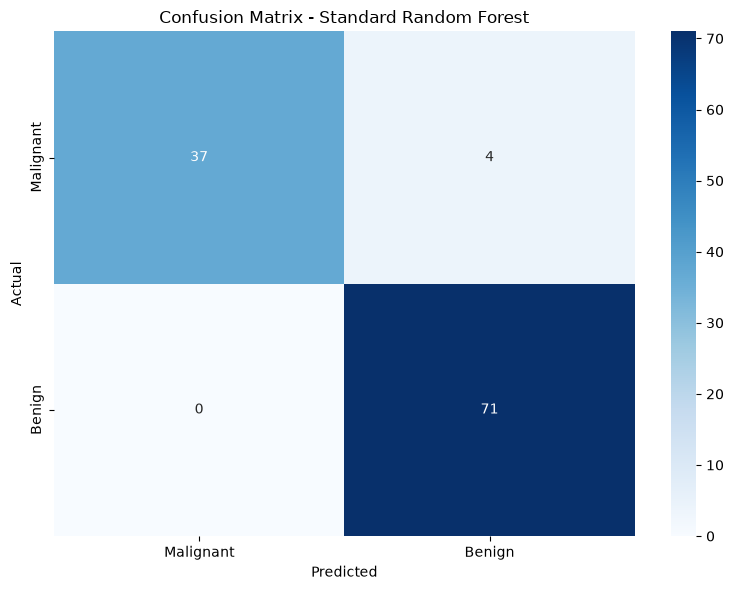


Confusion Matrix:
[[37  4]
 [ 0 71]]


In [5]:
# Confusion Matrix
avg_cm = np.mean(detail_cms, axis=0).astype(int)

TN = avg_cm[0, 0]
FP = avg_cm[0, 1]
FN = avg_cm[1, 0]
TP = avg_cm[1, 1]

custom_cm = np.array([
    [TP, FN],
    [FP, TN]
])

plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
#             xticklabels=['Benign', 'Malignant'],
#             yticklabels=['Benign', 'Malignant'])
sns.heatmap(custom_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix - Standard Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix:")
print(custom_cm)

## 7. Save Baseline Results

In [6]:
import json

# Capacity-matched to DP-RF (n_estimators=20, max_depth=4)
n_estimators = 20
max_depth = 4

parameters = {
    "n_estimators": n_estimators,
    "random_state": "run * 10 + 42",
    "n_jobs": -1,
    "max_depth": max_depth,
}


results_json = {
    "model_type": "Standard Random Forest", 
    "accuracy":  accuracy, 
    "confusion_matrix": cm.tolist(), 
    "parameters": parameters
}
results_json.update(extra.means())


# Store baseline results for comparison with DP model
baseline_results = {
    'model': 'Standard Random Forest',
    'n_estimators': n_estimators,
    'accuracy': accuracy,
    'f1_score': f1,
    'precision': precision,
    'recall': recall,
    'roc_auc': roc_auc
}
baseline_results.update(extra.means())

# Save to CSV
baseline_df = pd.DataFrame([baseline_results])
baseline_df.to_csv('baseline_results.csv', index=False)

# # Save to JSON file
with open('std_rf_report.json', 'w') as f:
    json.dump(results_json, f, indent=4)

print("Results saved to 'dp_rf_report.json'")

print("Baseline results saved to 'baseline_results.csv'")
print("\nBaseline Performance Summary:")
baseline_df

print("Added metrics:")
print(extra.describe())

Results saved to 'dp_rf_report.json'
Baseline results saved to 'baseline_results.csv'

Baseline Performance Summary:
Added metrics:
  Train Acc:      0.9871 ± 0.0030
  Balanced Acc:   0.9439 ± 0.0089
  AUROC:          0.9922 ± 0.0023
  Train Time (s): 0.0183 ± 0.0120
